In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression	
from sklearn.linear_model import Lasso	
from sklearn.linear_model import Ridge	
from sklearn.tree import DecisionTreeRegressor	
from sklearn.ensemble import RandomForestRegressor	
from sklearn.svm import SVR	
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [21]:
df = pd.read_csv('Admission_Predict_Ver1.1.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [22]:
df.shape

(500, 9)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [24]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [36]:
df.columns = df.columns.str.strip()

In [37]:
corr_matrix = df.drop('Serial No.', axis=1).corr()

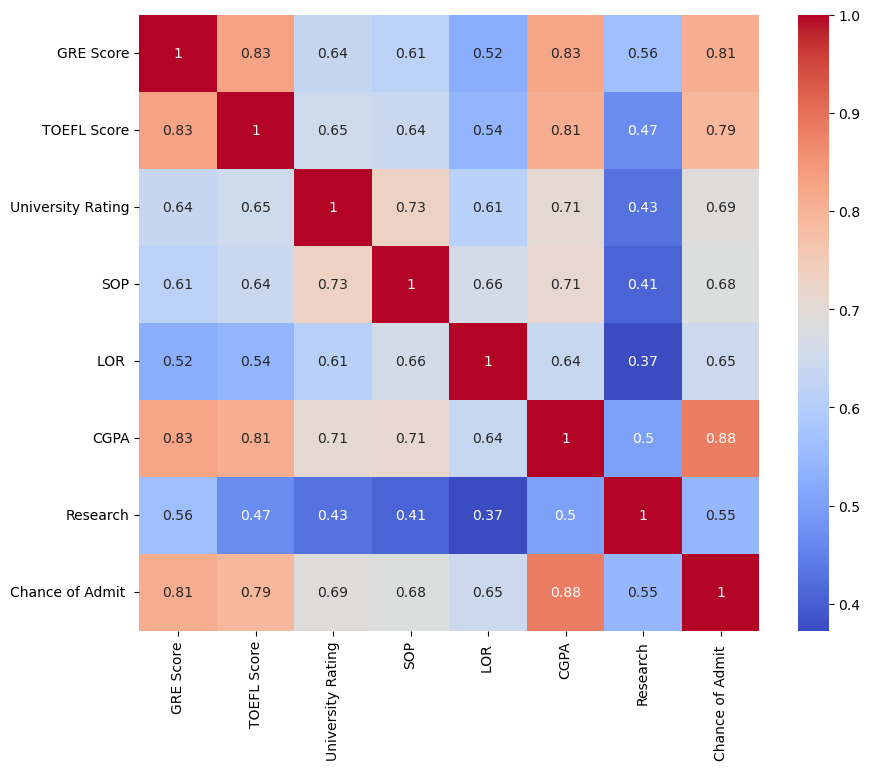

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

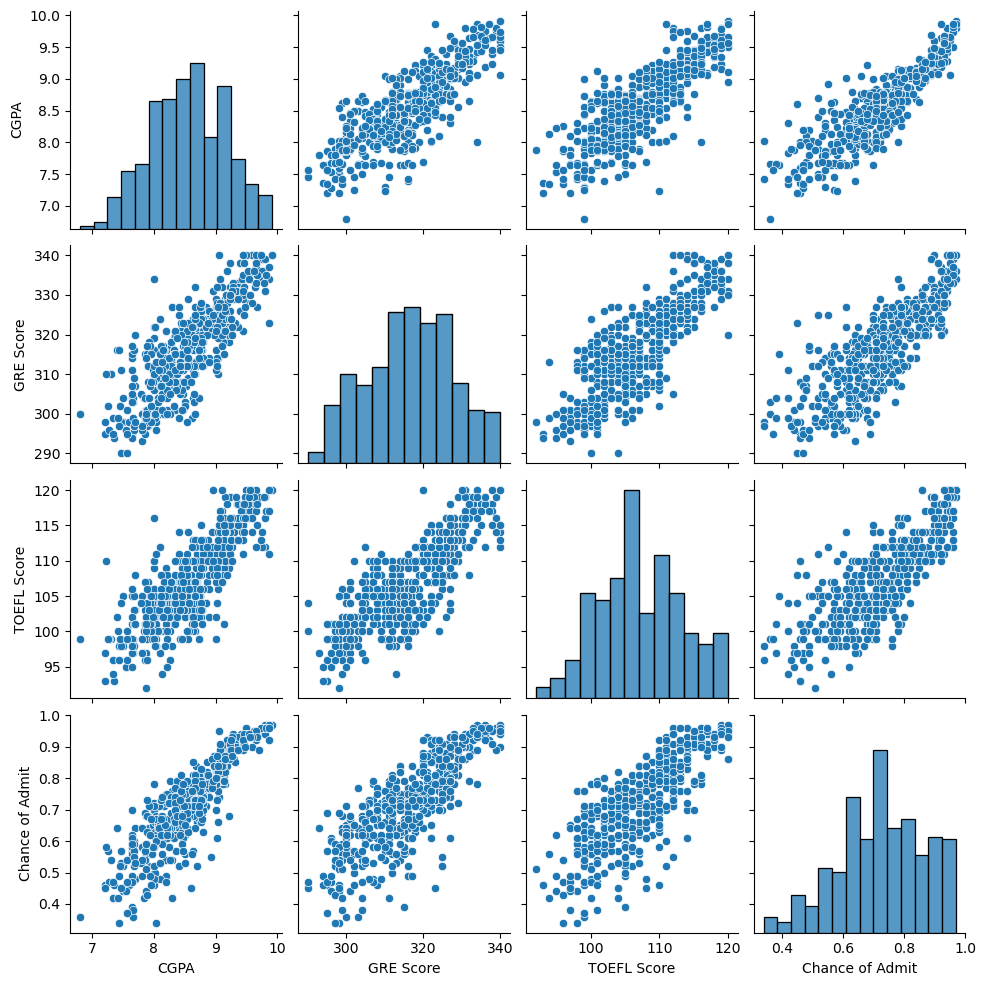

In [33]:
important_cols = ['CGPA', 'GRE Score', 'TOEFL Score', 'Chance of Admit']
sns.pairplot(df[important_cols])
plt.show()

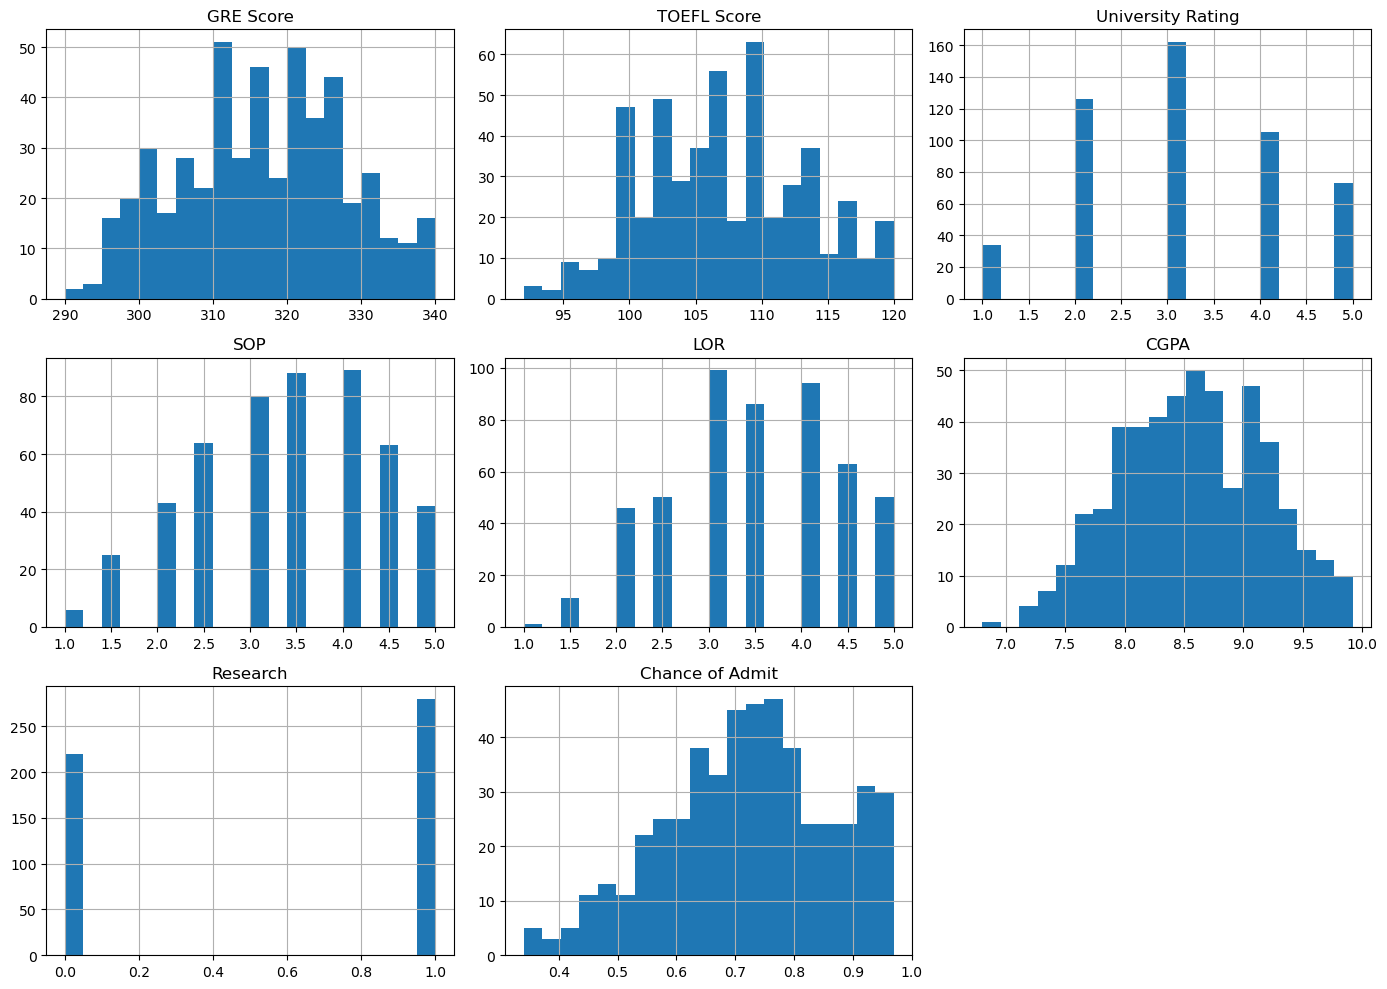

In [34]:
df.drop('Serial No.', axis=1).hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

In [38]:
df.drop('Serial No.', axis=1, inplace=True)

In [42]:
X = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

In [43]:
print(X.shape)
print(y.shape)

(500, 7)
(500,)


In [45]:
models = {
    'Linear Regression':{
        'model': LinearRegression(),
        'params': {}
    }, 
    'Lasso':{
        'model': Lasso(),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    },
    'Ridge':{
        'model': Ridge(),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    },
    'Decision Tree':{
        'model': DecisionTreeRegressor(),
        'params': {'max_depth': [2, 4, 6, 8, 10]}
    },
    'Random Forest':{
        'model': RandomForestRegressor(),
        'params': {'n_estimators': [50, 100, 200]}
    },
    'SVR':{
        'model': SVR(),
        'params': {'C': [0.1, 1, 10]}
    }    
}

results = []
for name, config in models.items():
    grid = GridSearchCV(config['model'], config['params'], cv=5)
    grid.fit(X,y)
    results.append({'model': name, 'best_score': grid.best_score_, 'best_params': grid.best_params_})

results_df = pd.DataFrame(results)
results_df

,model,best_score,best_params
0,Linear Regression,0.810802,{}
1,Lasso,0.810441,{'alpha': 0.001}
2,Ridge,0.810801,{'alpha': 0.001}
3,Decision Tree,0.720182,{'max_depth': 4}
4,Random Forest,0.780732,{'n_estimators': 200}
5,SVR,0.703892,{'C': 10}


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [48]:
print(X_train.shape) 
print(X_test.shape) 

(400, 7)
(100, 7)


In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.8214787365889662

In [54]:
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})
comparison

,Actual,Predicted
0,0.65,0.610565
1,0.80,0.759988
2,0.72,0.769930
3,0.95,0.968731
4,0.78,0.718991
5,0.68,0.721628
6,0.67,0.620686
7,0.77,0.694735
8,0.46,0.641404
9,0.76,0.776131
